<a href="https://colab.research.google.com/github/MayerT1/LiDAR_Dev/blob/main/Sewanee_2D_CNN_Patch_based_Multisensor_Fusion_GEDI_RS_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
!pip install gdal
!pip install laspy
!pip install lazrs
!pip install rasterio
!pip install retry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.3/84.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 640.9/640.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 5.0 MB/s eta 0:00:00


In [45]:


# Install necessary packages
!pip install geemap geopandas scikit-learn tensorflow

In [46]:
# Authenticate and initialize Earth Engine
import ee
import geemap
import geemap.chart as chart
ee.Authenticate()
ee.Initialize(project='servir-sco-assets')
Map = geemap.Map()



from google.colab import drive
drive.mount('/content/drive/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [47]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
import tensorflow as tf
from tensorflow.keras import layers, models
import folium


In [50]:
%cd /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32

/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32


In [51]:
# !mkdir test
# !mkdir train
# !mkdir val

In [52]:
# !mkdir y_pai
# !mkdir y_pai/y_test
# !mkdir y_pai/y_train
# !mkdir y_pai/y_val

In [53]:
# !mkdir y_fhd
# !mkdir y_fhd/y_test
# !mkdir y_fhd/y_train
# !mkdir y_fhd/y_val

In [54]:
# !mkdir y_ch
# !mkdir y_ch/y_test
# !mkdir y_ch/y_train
# !mkdir y_ch/y_val

In [49]:
s1Ascending_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021")
DEMindices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021")
GEDIindicesA_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/GEDIindicesA_2021")
GEDIindicesB_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/GEDIindicesB_2021")
HLS_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/HLS_2021")
LandsatComposite_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatComposite_2021")
LandsatIndices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatIndices_2021")
S2Composite_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Composite_2021")
S2Indices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Indices_2021")
landsatTasseledCapIndices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/landsatTasseledCapIndices_2021")
ROI = ee.FeatureCollection('projects/servir-sco-assets/assets/Rx_Fire/Vector_Data/Sewanee_Domain')

# Map.addLayer(ROI, {}, 'ROI')
# Map.addLayer(s1Ascending_2021, {}, 's1Ascending_2021')
# Map.addLayer(DEMindices_2021, {}, 'DEMindices_2021')
# Map.addLayer(GEDIindicesA_2021, {}, 'GEDIindicesA_2021')
# Map.addLayer(GEDIindicesB_2021, {}, 'GEDIindicesB_2021')
# Map.addLayer(HLS_2021, {}, 'HLS_2021')
# Map.addLayer(LandsatComposite_2021, {}, 'LandsatComposite_2021')
# Map.addLayer(LandsatIndices_2021, {}, 'LandsatIndices_2021')
# Map.addLayer(S2Composite_2021, {}, 'S2Composite_2021')
# Map.addLayer(S2Indices_2021, {}, 'S2Indices_2021')
# Map.addLayer(landsatTasseledCapIndices_2021, {}, 'landsatTasseledCapIndices_2021')


# stacked = s1Ascending_2022.addBands(s1Descending_2022).addBands(DEMindices_2022).addBands(LandsatComposite_2022).addBands(LandsatIndices_2022).addBands(landsatTasseledCapIndices_2022).addBands(HLS_2022).addBands(S2Composite_2022).addBands(S2Indices_2022)
stacked = s1Ascending_2021.addBands(DEMindices_2021).addBands(LandsatComposite_2021).addBands(LandsatIndices_2021).addBands(landsatTasseledCapIndices_2021).addBands(HLS_2021).addBands(S2Composite_2021).addBands(S2Indices_2021)

Map.addLayer(stacked, {}, 'stacked');

#//////////////////////////////////////////////////////////////////////////////////
glad = ee.Image("projects/glad/GLCLU2020/Forest_height_2020").clip(ROI)
Map.addLayer(glad, {}, "glad")
glad = glad.gte(1).select(['b1']).rename(['class']);
#print("glad", glad)

classMask = GEDIindicesA_2021.addBands(glad)
Map.addLayer(classMask, {}, "classMask")
#print("classMask", classMask)

proj = GEDIindicesA_2021.projection()
grid = ROI.geometry().coveringGrid(proj, 30)
grid = ee.FeatureCollection(grid).randomColumn("random", 42);
#print("spatial_partition number of boxes in the grid", grid.size())
val_samp = grid.filter('random <= 0.1').set("samp_type","val_samp");
test_samp = grid.filter('random <= 0.3 and random >= 0.1').set("samp_type","test_samp");
train_samp = grid.filter('random >= 0.3').set("samp_type","train_samp");

#rint('val_samp 10%', val_samp.size());
Map.addLayer(val_samp, {"color": "blue"}, "val_samp 10%")

#print('test_samp 20%', test_samp.size());
Map.addLayer(test_samp, {"color": "red"}, "test_samp 20%")

#print('train_samp 70%', train_samp.size());
Map.addLayer(train_samp, {"color": "green"}, "train_samp 70%")

Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [56]:
# ================================================================
# BLOCK 1 – create chips
# ================================================================
import ee, os, requests, shutil, multiprocessing, random
from retry import retry

# ee.Initialize(opt_url="https://earthengine-highvolume.googleapis.com")

# ------------ parameters you may change -------------------------
PIXELS      = 32         # chip width / height
SCALE       = 10           # metres per pixel
PERCENTAGE  = .1           # % of features to keep
N_WORKERS   = 12           # parallel download processes
BASE_DIR    = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32"
# ----------------------------------------------------------------
DIMENSIONS  = f"{PIXELS}x{PIXELS}"
HALF_BUFFER = PIXELS * SCALE / 2

# # ------------ your stacked image --------------------------------
# stacked = (
#     s1Ascending_2021
#       .addBands(DEMindices_2021)
#       .addBands(LandsatComposite_2021)
#       .addBands(LandsatIndices_2021)
#       .addBands(landsatTasseledCapIndices_2021)
#       .addBands(HLS_2021)
#       .addBands(S2Composite_2021)
#       .addBands(S2Indices_2021)
# )

# ------------ helpers -------------------------------------------
def get_geoms(fc):
    """Return client-side list of GeoJSON geometries."""
    return fc.aggregate_array(".geo").getInfo()

@retry(tries=10, delay=1, backoff=2)
def download_chip(idx, geom, out_dir, prefix="chip_"):
    """Download one NPY chip centred on *geom*."""
    region = ee.Geometry(geom).centroid(maxError=1).buffer(HALF_BUFFER).bounds()
    url    = stacked.getDownloadURL({"region": region,
                                     "dimensions": DIMENSIONS,
                                     "format": "NPY"})
    r = requests.get(url, stream=True)
    r.raise_for_status()
    fn = os.path.join(out_dir, f"{prefix}{str(idx).zfill(6)}.npy")
    with open(fn, "wb") as fp:
        shutil.copyfileobj(r.raw, fp)

def process_set(fc, name):
    # -------- sample PERCENTAGE % reproducibly
    sampled = (fc.randomColumn("rnd", seed=42)
                 .filter(f"rnd < {PERCENTAGE/100.0}"))
    n = sampled.size().getInfo()
    print(f"\n{name.upper()} → {n} chips will be created "
          f"({PERCENTAGE}% of original).")
    if input("Type 'y' + <Enter> to proceed: ").lower() != "y":
        print("Skipped.")
        return

    out_dir = os.path.join(BASE_DIR, name)
    os.makedirs(out_dir, exist_ok=True)

    geoms = get_geoms(sampled)
    pool  = multiprocessing.Pool(N_WORKERS)
    pool.starmap(download_chip,
                 [(i, g, out_dir) for i, g in enumerate(geoms)])
    pool.close(); pool.join()
    print(f"✓  {n} chips written → {out_dir}")

# ------------ run all three sets --------------------------------
SETS = {"train": train_samp, "test": test_samp, "val": val_samp}
for set_name, fc in SETS.items():
    process_set(fc, set_name)


TRAIN → 56 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  56 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/train

TEST → 14 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  14 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/test

VAL → 11 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  11 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/val


Chip shape: (32, 32, 48)
Band names: ('VV', 'VH', 'ratio', 'ndratio', 'VV_1', 'VH_1', 'ratio_1', 'ndratio_1', 'red', 'green', 'blue', 'nir', 'swir1', 'swir2', 'NDVI', 'NDWI', 'MNDWI', 'SAVI', 'NDMI', 'NDBI', 'NBR', 'brightness', 'greenness', 'wetness', 'fourth', 'fifth', 'sixth', 'NDVI_1', 'NDWI_1', 'MNDWI_1', 'SAVI_1', 'NDMI_1', 'NDBI_1', 'NBR_1', 'red_1', 'green_1', 'blue_1', 'nir_1', 'swir1_1', 'swir2_1', 'S2_NDVI', 'S2_NDWI', 'S2_EVI', 'S2_MNDWI', 'S2_SAVI', 'S2_NDMI', 'S2_NDBI', 'S2_NBR')


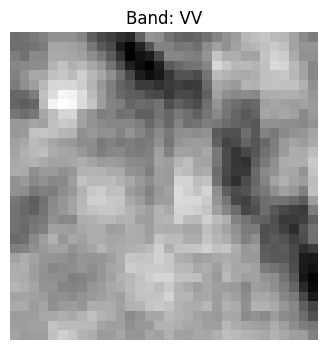

Map(center=[35.235012055380786, -85.97693593259385], controls=(WidgetControl(options=['position', 'transparent…

In [57]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geemap, ee
# ee.Initialize(opt_url="https://earthengine-highvolume.googleapis.com")

# ---------- Load the .npy chip ----------
npy_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/train/chip_000001.npy"
chip_struct = np.load(npy_path)

# Convert structured array to regular 3D NumPy array
band_names = chip_struct.dtype.names
chip_array = np.stack([chip_struct[name] for name in band_names], axis=-1)

print("Chip shape:", chip_array.shape)
print("Band names:", band_names)

# ---------- Visualize first band ----------
plt.figure(figsize=(4, 4))
plt.imshow(chip_array[:, :, 0], cmap="gray")
plt.title(f"Band: {band_names[0]}")
plt.axis("off")
plt.show()

# ---------- Display on a Map ----------
PIXELS = 32
SCALE = 10
HALF_BUFFER = PIXELS * SCALE / 2
PERCENTAGE = 10
IDX = 1  # chip_000001 index

sampled_train = (
    train_samp.randomColumn("rnd", seed=42)
              .filter(f"rnd < {PERCENTAGE / 100.0}")
)

geom_list = sampled_train.aggregate_array(".geo").getInfo()
chip_geom = ee.Geometry(geom_list[IDX])
chip_reg = chip_geom.centroid(maxError=1).buffer(HALF_BUFFER).bounds()

m = geemap.Map()
m.addLayer(chip_reg, {"color": "red"}, "chip_000001 footprint")
m.centerObject(chip_reg, 11)
display(m)

In [58]:
y_stacked_fhd = GEDIindicesB_2021.select("fhd_normal")#GEDIindicesA_2022.select('rh98')#GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
# print(y_stacked_fhd.bandNames())
Map.addLayer(y_stacked_fhd, {}, 'y_stacked_fhd')

y_stacked_ch = GEDIindicesA_2021.select('rh98')#GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
# print(y_stacked_ch.bandNames())
Map.addLayer(y_stacked_ch, {}, 'y_stacked_ch')

y_stacked_pai = GEDIindicesB_2021.select("pai")#GEDIindicesA_2022.select('rh98')#GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
# print(y_stacked_pai.bandNames())
Map.addLayer(y_stacked_pai, {}, 'y_stacked_pai')


Map


Map(bottom=52041.0, center=[35.395767045339056, -444.71008300781256], controls=(WidgetControl(options=['positi…

In [ ]:
# ================================================================
# BLOCK – create target chips for y_fhd, y_ch, y_pai
# ================================================================
import ee, os, requests, shutil, multiprocessing
from retry import retry

# ------------ parameters you may change -------------------------
PIXELS      = 32         # chip width / height
SCALE       = 10           # metres per pixel
PERCENTAGE  = 0.1          # % of features to keep
N_WORKERS   = 12           # parallel download processes
BASE_DIR    = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32"
# ----------------------------------------------------------------
DIMENSIONS  = f"{PIXELS}x{PIXELS}"
HALF_BUFFER = PIXELS * SCALE / 2

# ------------ target stacks dictionary --------------------------
target_stacks = {
    "y_fhd": y_stacked_fhd,
    "y_ch": y_stacked_ch,
    "y_pai": y_stacked_pai
}

# ------------ helpers -------------------------------------------
def get_geoms(fc):
    """Return client-side list of GeoJSON geometries."""
    return fc.aggregate_array(".geo").getInfo()

@retry(tries=10, delay=1, backoff=2)
def download_chip(idx, geom, out_dir, stack, prefix="chip_"):
    """Download one NPY chip centred on *geom*."""
    region = ee.Geometry(geom).centroid(maxError=1).buffer(HALF_BUFFER).bounds()
    url    = stack.getDownloadURL({
        "region": region,
        "dimensions": DIMENSIONS,
        "format": "NPY"
    })
    r = requests.get(url, stream=True)
    r.raise_for_status()
    fn = os.path.join(out_dir, f"{prefix}{str(idx).zfill(6)}.npy")
    with open(fn, "wb") as fp:
        shutil.copyfileobj(r.raw, fp)

def process_set(fc, name, stack, subfolder):
    """Sample, prompt, download chips for a given set and target stack."""
    # Sample PERCENTAGE % reproducibly
    sampled = (fc.randomColumn("rnd", seed=42)
                 .filter(f"rnd < {PERCENTAGE / 100.0}"))
    n = sampled.size().getInfo()
    print(f"\n{(subfolder + ' / ' + name).upper()} → {n} chips will be created "
          f"({PERCENTAGE}% of original).")
    if input("Type 'y' + <Enter> to proceed: ").lower() != "y":
        print("Skipped.")
        return

    out_dir = os.path.join(BASE_DIR, subfolder, name)
    os.makedirs(out_dir, exist_ok=True)

    geoms = get_geoms(sampled)
    pool = multiprocessing.Pool(N_WORKERS)
    pool.starmap(download_chip, [(i, g, out_dir, stack) for i, g in enumerate(geoms)])
    pool.close(); pool.join()
    print(f"✓  {n} chips written → {out_dir}")

# ------------ run all targets for all sets -----------------------
SETS = {"y_train": train_samp, "y_test": test_samp, "y_val": val_samp}

for subfolder, stack in target_stacks.items():
    for set_name, fc in SETS.items():
        process_set(fc, set_name, stack, subfolder)



Y_FHD / Y_TRAIN → 56 chips will be created (0.1% of original).


✓  56 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_fhd/y_train

Y_FHD / Y_TEST → 14 chips will be created (0.1% of original).


✓  14 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_fhd/y_test

Y_FHD / Y_VAL → 11 chips will be created (0.1% of original).


✓  11 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_fhd/y_val

Y_CH / Y_TRAIN → 56 chips will be created (0.1% of original).


✓  56 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_ch/y_train

Y_CH / Y_TEST → 14 chips will be created (0.1% of original).


✓  14 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_ch/y_test

Y_CH / Y_VAL → 11 chips will be created (0.1% of original).


✓  11 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_ch/y_val

Y_PAI / Y_TRAIN → 56 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  56 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_pai/y_train

Y_PAI / Y_TEST → 14 chips will be created (0.1% of original).


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geemap, ee
# ee.Initialize(opt_url="https://earthengine-highvolume.googleapis.com")

# ---------- Load the .npy chip ----------
npy_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_fhd/y_train/chip_000001.npy"
chip_struct = np.load(npy_path)

# Convert structured array to regular 3D NumPy array
band_names = chip_struct.dtype.names
chip_array = np.stack([chip_struct[name] for name in band_names], axis=-1)

print("Chip shape:", chip_array.shape)
print("Band names:", band_names)

# ---------- Visualize first band ----------
plt.figure(figsize=(4, 4))
plt.imshow(chip_array[:, :, 0], cmap="gray")
plt.title(f"Band: {band_names[0]}")
plt.axis("off")
plt.show()

# ---------- Display on a Map ----------
PIXELS = 128
SCALE = 10
HALF_BUFFER = PIXELS * SCALE / 2
PERCENTAGE = 10
IDX = 1  # chip_000001 index

sampled_train = (
    train_samp.randomColumn("rnd", seed=42)
              .filter(f"rnd < {PERCENTAGE / 100.0}")
)

geom_list = sampled_train.aggregate_array(".geo").getInfo()
chip_geom = ee.Geometry(geom_list[IDX])
chip_reg = chip_geom.centroid(maxError=1).buffer(HALF_BUFFER).bounds()

m = geemap.Map()
m.addLayer(chip_reg, {"color": "red"}, "chip_000001 footprint")
m.centerObject(chip_reg, 11)
display(m)